# 🌟 COSMIC v0.0.1 - Compatibilidad Automática

**Este notebook ha sido actualizado para COSMIC v0.0.1**

## ✨ Mejoras Disponibles
- **Estructura modular**: `cosmic.core`, `cosmic.io`, `cosmic.preprocess`, `cosmic.analysis`
- **Imports modernos**: Específicos y organizados
- **API mejorada**: Mejor manejo de errores y configuración
- **Compatibilidad total**: El código existente sigue funcionando

## 🔄 Migración Opcional
Para usar las nuevas funcionalidades:
```python
# Nuevo (recomendado)
from cosmic.analysis.analyzer import ClusterAnalyzer
from cosmic.core.clustering import Clustering
from cosmic.io.loader import DataLoader

# Legacy (sigue funcionando)
from COSMIC import ClusterAnalyzer
from clustering import HDBSCANClustering
from data_loader import DataLoader
```

📚 **Documentación**: `/docs/reference/NOTEBOOK_MIGRATION_GUIDE.md`

In [75]:
# COSMIC initial version - Alpha Version - 15/09/2023

# Modules

from astropy.io import ascii
from astropy.table import QTable,join
from astropy.coordinates import SkyCoord, Galactocentric
from astropy.visualization import quantity_support
import hdbscan
import seaborn as sns
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from zero_point import zpt
import matplotlib.ticker as ticker
from astropy.coordinates import SkyCoord

# Here loading some functions from the modules.
zpt.load_tables()
quantity_support()

# Set values of sigma in GAIA DR3
sigmaG_0, sigmaGBP_0, sigmaGRP_0 = 0.0027553202, 0.0027901700, 0.0037793818;

def load_data(data_file,format='ascii.ecsv',fidelity_file=None):
    data = QTable.read(data_file,guess=False,format=format)
    ## Add astrometric fidelity when available
    if fidelity_file != None:
        fidelity_data = QTable.read(fidelity_file, guess=False, format='ascii.ecsv')
        data = join(data, fidelity_data, keys='source_id',metadata_conflicts='silent')
        ## Edit table columns for better read
    data.rename_columns(['phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag', 'bp_rp'],['Gmag', 'G_BPmag', 'G_RPmag', 'BP-RP'])
    return data
    
def quality_selection(data,threshold_fidelity,threshold_parallax_error=None,threshold_pm_error=None):
    fidelity_selection = (threshold_fidelity < data['fidelity'])
    data = data[fidelity_selection]
    # Mask table to delete wrong data
    columns_to_check = ['ra','dec','pmra','pmdec','parallax','Gmag','G_BPmag','G_RPmag', 'l', 'b']
    mask = np.zeros(len(data), dtype=bool)
    for column in columns_to_check:
        mask |= ~np.isfinite(data[column])
    data = data[~mask]
    return data
    
def correct_zp_parallax(data):
    data['zpvals'] = zpt.get_zpt(data['Gmag'], data['nu_eff_used_in_astrometry'], data['pseudocolour'], data['ecl_lat'], data['astrometric_params_solved'])*u.mas
    data['zpvals'] = np.ma.masked_invalid(data['zpvals']).filled(0)
    data['parallax_corrected'] = data['parallax'] - data['zpvals']
    data.rename_columns(['parallax'],['parallax_observed']);
    return data

def correct_pm(data: Table) -> Table:
    # Create corrected columns
    data['pmra_corr'] = data['pmra']
    data['pmdec_corr'] = data['pmdec']
    
    # Rename original columns
    data.rename_columns(['pmra', 'pmdec'], ['pmra_obs', 'pmdec_obs'])
    
    # Define the internal function for corrections
    def edr3ToICRF(pmra, pmdec, ra, dec, G):
        
        if G >= 13*u.mag:
            return pmra, pmdec
        
        coeffs = np.array([
            [0.0, 9.0, 18.4, 33.8, -11.3],
            [9.0, 9.5, 14.0, 30.7, -19.4],
            [9.5, 10.0, 12.8, 31.4, -11.8],
            [10.0, 10.5, 13.6, 35.7, -10.5],
            [10.5, 11.0, 16.2, 50.0, 2.1],
            [11.0, 11.5, 19.4, 59.9, 0.2],
            [11.5, 11.75, 21.8, 64.2, 1.0],
            [11.75, 12.0, 17.7, 65.6, -1.9],
            [12.0, 12.25, 21.3, 74.8, 2.1],
            [12.25, 12.5, 25.7, 73.6, 1.0],
            [12.5, 12.75, 27.3, 76.6, 0.5],
            [12.75, 13.0, 34.9, 68.9, -2.9]
        ])
        omegaX, omegaY, omegaZ = coeffs[(coeffs[:,0]*u.mag <= G) & (coeffs[:,1]*u.mag > G), 2:5][0]
        pmra_corr = -1 * np.sin(np.radians(dec)) * np.cos(np.radians(ra)) * omegaX - np.sin(np.radians(dec)) * np.sin(np.radians(ra)) * omegaY + np.cos(np.radians(dec)) * omegaZ
        pmdec_corr = np.sin(np.radians(ra)) * omegaX - np.cos(np.radians(ra)) * omegaY
        
        return (pmra - pmra_corr*(u.mas/u.yr) / 1000.0), (pmdec - pmdec_corr*(u.mas/u.yr) / 1000.0)
    
    # Loop through each row in the table to apply corrections
    for row in data:
        pmra_corr, pmdec_corr = edr3ToICRF(row['pmra_obs'], row['pmdec_obs'], row['ra'], row['dec'], row['Gmag'])
        row['pmra_corr'] = pmra_corr
        row['pmdec_corr'] = pmdec_corr

    return data

def HDBSCAN_COSMIC(data, algorithm='best', min_cluster_size=24, metric='euclidean', 
                   allow_single_cluster=True, cluster_selection_method='leaf', plot_option=0,core_dist_n_jobs=-1):
    
    # Convert data to pandas DataFrame if necessary
    if isinstance(data, QTable):
        data_panda = data['l', 'b', 'pmra_corr', 'pmdec_corr', 'parallax_corrected'].to_pandas()
    elif isinstance(data, pd.DataFrame):
        data_panda = data
    else:
        raise TypeError("Data should be either a QTable or a Pandas DataFrame.")
        
    # Run clustering algorithm
    clusterer = hdbscan.HDBSCAN(algorithm=algorithm, metric=metric, 
                                allow_single_cluster=allow_single_cluster, 
                                min_cluster_size=min_cluster_size, 
                                core_dist_n_jobs=core_dist_n_jobs, 
                                cluster_selection_method=cluster_selection_method).fit(data_panda)
    
    # Add cluster, probability, and colors columns to the table
    data['cluster'] = clusterer.labels_
    data['probability'] = clusterer.probabilities_
    color_palette = sns.color_palette('bright', len(np.unique(clusterer.labels_)))
    data['cluster_member_colors'] = [color_palette[x] if x >= 0 else (0.5, 0.5, 0.5) for x in clusterer.labels_]
    data['outlier_score'] = clusterer.outlier_scores_

    # Plotting
    if plot_option in [1, 2, 3]:
        fig_ct, ax_ct = plt.subplots(1, 1, layout='constrained', figsize=(8, 6))
        clusterer.condensed_tree_.plot(select_clusters=True, 
                                       selection_palette=sns.color_palette("bright", 4), 
                                       cmap=sns.color_palette("mako", as_cmap=True), axis=ax_ct)
        ax_ct.set(ylabel=r'$\lambda$ value')
        ax_ct.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax_ct.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax_ct.tick_params(axis='both', which='both', direction='in')

        if plot_option in [1, 3]:
            plt.show()
        if plot_option in [2, 3]:
            fig_ct.savefig('condensed_cluster_tree_NGC6383.pdf')
    
    return data
    
def center_determination(data):
    ra = data['ra_gaia']  # RA values
    dec = data['dec_gaia']  # Dec values
    ra_dec = np.vstack((ra,dec))
    kde = gaussian_kde(ra_dec,bw_method='silverman')
    added_space_ra = (max(ra)-min(ra))/10
    added_space_dec = (max(dec)-min(dec))/10
    grid_ra = np.linspace(min(ra)-added_space_ra, max(ra)+added_space_ra, 1000)
    grid_dec = np.linspace(min(dec)-added_space_dec, max(dec)+added_space_dec, 1000)
    grid_ra, grid_dec = np.meshgrid(grid_ra, grid_dec)
    grid_points = np.vstack((grid_ra.flatten(), grid_dec.flatten()))
    kde.set_bandwidth(bw_method=kde.factor/3.5)
    # Evaluate the KDE at the grid points
    density = kde(grid_points)
    # Reshape the density values to match the grid shape
    density = density.reshape(grid_ra.shape)
    max_density_idx = np.nanargmax(density)
    max_density_coords = (grid_ra.flatten()[max_density_idx], grid_dec.flatten()[max_density_idx])
    return density, max_density_coords, grid_ra, grid_dec, kde.factor
def graph_center_determination(data,projection=None,savefig=None,prob_number=[60,70,80,90]):
    subplot_kw = {'projection': projection}
    center = []
    kde_factors  = []
    prob_number = np.array(prob_number)/100
    if len(prob_number) == 1:
        fig_kde, ax_kde = plt.subplots(1, layout='tight', figsize=(15,15), subplot_kw=subplot_kw)
    if len(prob_number) == 2:
        fig_kde, ax_kde = plt.subplots(1,2, layout='tight', figsize=(17.5,7), subplot_kw=subplot_kw)
    if len(prob_number) == 3:
        fig_kde, ax_kde = plt.subplots(1,3, layout='tight', figsize=(15,15), subplot_kw=subplot_kw)
    if len(prob_number) == 4:
        fig_kde, ax_kde = plt.subplots(2,2, layout='tight', figsize=(15,15), subplot_kw=subplot_kw)
    if projection == None:
        transform = None
    for i,ax in zip(prob_number,ax_kde.flatten()):
        print(str(round(i*100))+'%')
        probability_selection = (data['probability'] >= i)
        iterative_data = data[probability_selection]
        cent_det = center_determination(iterative_data)    
        density = cent_det[0]
        grid_ra,grid_dec = cent_det[2],cent_det[3]
        kde_factor = cent_det[4]
        kde_factors.append(kde_factor)
        levels = np.linspace(density.min(), density.max(), 15)
        contour = ax.contour(grid_ra, grid_dec, density, cmap='viridis', linestyles='solid', norm='linear', levels=levels)
        ax.coords.grid(True, color='gray', linestyle='dotted')
        ax.coords[0].set_format_unit(u.deg)
        ax.set(xlabel=r'$\alpha$ [{}]'.format(data['ra_gaia'].unit), ylabel=r'$\delta$ [{}]'.format(data['dec_gaia'].unit))
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.tick_params(axis='both', which='both', direction='in')
        ax.set_aspect('equal')
        # Overlay sources
        ax.scatter(iterative_data['ra_gaia'],iterative_data['dec_gaia'],color='yellow',s=30,marker='*',transform=ax.get_transform(projection))
        ax.tick_params(axis='both', which='both')
        max_density_coords = cent_det[1]
        # Plot the center of the cluster
        ax.scatter(max_density_coords[0],max_density_coords[1],marker='1',s=400,color='blue',transform=ax.get_transform(projection))
        ax.axvline(max_density_coords[0],color='lavender',ls='--')
        ax.axhline(max_density_coords[1],color='lavender',ls='--')
        ax.set_facecolor('black')
        legend_label = r'$C = ({:.4f},{:.4f})\;{}$'.format(max_density_coords[0].value,max_density_coords[1].value,u.deg)
        ax.set_title(str(round(int(i*101)))+'% probability members')
        ax.legend([legend_label], loc='best',shadow=True,framealpha=0.8);
        center.append(max_density_coords)
    if savefig != None:
        fig_kde.savefig(savefig+'center_determination.pdf',dpi=1000,bbox_inches='tight');
    return center, kde_factors

In [76]:
# Import data
data_gaia_test = QTable.read('25_arcmin_GAIA_DR3.ecsv',guess=False,format='ascii.ecsv')
fidelity_data = QTable.read('fidelity_ps.ecsv', guess=False, format='ascii.ecsv')
# Parallax selection
parallax_selection_test = (0.5 * u.mas < data_gaia_test['parallax']) & (data_gaia_test['parallax'] < 2 * u.mas) & (data_gaia_test['parallax_error'] < 0.5 * u.mas)
data_gaia_test = join(data_gaia_test[parallax_selection_test], fidelity_data, keys='source_id',metadata_conflicts='silent')
print(len(data_gaia_test))

14002


In [77]:
data_gaia = load_data('25_arcmin_GAIA_DR3.ecsv',fidelity_file='fidelity_ps.ecsv')

In [78]:
data_gaia = quality_selection(data_gaia, 0.5)

In [79]:
parallax_selection = (0.5 * u.mas < data_gaia['parallax']) & (data_gaia['parallax'] < 2 * u.mas) & (data_gaia['parallax_error'] < 0.5 * u.mas)

data_gaia = data_gaia[parallax_selection]

In [80]:
data_gaia = correct_zp_parallax(data_gaia)

In [81]:
data_gaia = correct_pm(data_gaia)

In [83]:
data_gaia['pmra_corr','pmdec_corr','Gmag'][data_gaia['Gmag'] < 13*u.mag]

pmra_corr,pmdec_corr,Gmag
mas / yr,mas / yr,mag
float64,float64,float32
3.9854801424513537,-1.68246976528381,12.676942825317383
1.0673602347742164,-1.0629918083076177,10.552926063537598
4.437229747703155,-9.100365953025388,10.590514183044434
-0.9414831479013063,-3.0078515079507775,12.313931465148926
3.8747781890639508,1.5959118687929046,10.901275634765625
2.7126957006852748,-13.387952109725248,11.889472007751465
-0.7937136472484219,-1.6079085388061043,12.510622024536133
-2.549580641119395,-9.492151538497737,12.00003719329834


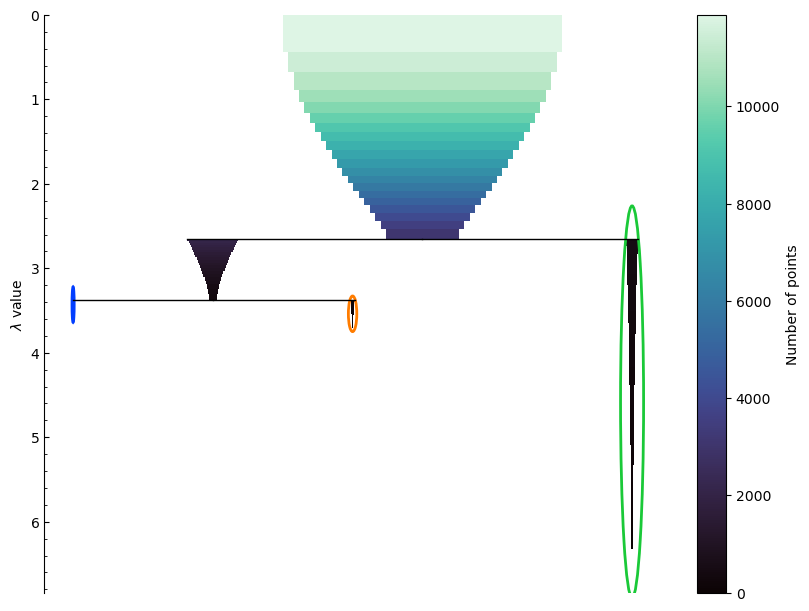

In [11]:
data_gaia = HDBSCAN_COSMIC(data_gaia, algorithm='best', metric='euclidean', allow_single_cluster=True, min_cluster_size=24, cluster_selection_method='leaf',plot_option=3)